## Sample Weights — зачем и что реализуем

### Проблема

Triple Barrier метки перекрываются во времени. Каждая метка смотрит вперёд на N баров — и соседние метки неизбежно захватывают одни и те же ценовые движения:

```
Бар t0: метка активна → [t0, t0 + 5 дней]
Бар t1: метка активна → [t1, t1 + 5 дней]

Если t1 < t0 + 5 дней — обе метки зависят от одних и тех же баров
```

На dollar bars ~30m с горизонтом 5 дней перекрытие будет у **почти каждой пары соседних меток** — ~240 общих баров. Это нарушает IID предположение на котором основан весь ML. Без исправления модель будет переобучаться на периодах высокой активности и OOB accuracy Random Forest окажется завышенной.

---

### Что реализуем

**1. Concurrent Labels — сколько меток активны одновременно**

Для каждого бара `t` считаем сколько меток из всей выборки активны в этот момент — то есть их интервал `[t0, t1]` включает `t`:

```python
c_t = число меток активных в момент t
```

Чем больше `c_t` — тем менее уникальна каждая из этих меток. Это основа для всего остального.

**2. Average Uniqueness — насколько уникальна каждая метка**

Уникальность метки в момент `t` — обратная величина от числа перекрытий:

```python
u_t = 1 / c_t        # уникальность в момент t
ū_i = mean(u_t)      # средняя уникальность за жизнь метки [t0, t1]
```

Если `ū_i = 1.0` — метка полностью уникальна, не перекрывается ни с кем. Если `ū_i = 0.1` — 90% информации в этой метке уже содержится в других метках выборки.

**3. Sample Weights по Return Attribution**

Вес каждого наблюдения пропорционален уникальному абсолютному return который оно несёт — с поправкой на перекрытие:

```python
w_i = |Σ(r_t / c_t)|   за период [t0, t1]
```

Сильное движение с низким overlap → высокий вес — модель уделяет ему больше внимания. Слабое движение с высоким overlap → низкий вес — модель его почти игнорирует. Это прямая реализация идеи de Prado: каждое наблюдение должно весить пропорционально уникальной информации которую оно несёт.

**4. Sequential Bootstrap**

Стандартный bootstrap при обучении Random Forest случайно семплирует наблюдения с заменой — и с высокой вероятностью выбирает перекрывающиеся метки в одно дерево. Sequential bootstrap снижает эту вероятность: каждое следующее наблюдение выбирается с вероятностью пропорциональной его уникальности относительно уже выбранных:

```
Стандартный bootstrap:  avg uniqueness ≈ 0.60
Sequential bootstrap:   avg uniqueness ≈ 0.70
```

Деревья становятся более разнообразными и менее переобученными.

**5. Time Decay**

Рыночные режимы меняются — паттерны 2020 года могут не работать в 2025. Time decay снижает вес старых наблюдений через параметр `c`:

```python
c =  1.0  → нет затухания, все наблюдения равны
c =  0.5  → линейное затухание, все веса > 0
c =  0.0  → веса сходятся к нулю для старых наблюдений
c = -0.5  → старые 50% наблюдений получают вес = 0
```

**6. Class Weights**

При дисбалансе классов добавляем `class_weight='balanced'` в sklearn — это автоматически умножает веса наблюдений на коэффициент обратный частоте класса. Дополняет sample weights, не заменяет их.

---

### Приоритеты реализации

| Компонент | Приоритет | Зачем |
|-----------|-----------|-------|
| `mpNumCoEvents` | обязательно | считает перекрытия — основа для всего |
| `mpSampleTW` (avg uniqueness) | обязательно | уникальность каждой метки |
| `mpSampleW` (return weights) | обязательно | итоговый вес наблюдения |
| Sequential Bootstrap | желательно | разнообразие деревьев RF |
| Time Decay | желательно | снижение влияния старых данных |
| Class Weights | просто | `balanced` в одну строку |

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from pathlib import Path

# Concurrent Labels

Считаем для каждого бара сколько меток активны одновременно — то есть сколько интервалов `[t0, t1]` из нашей разметки включают этот бар. Это `c_t` — основа для вычисления весов наблюдений.

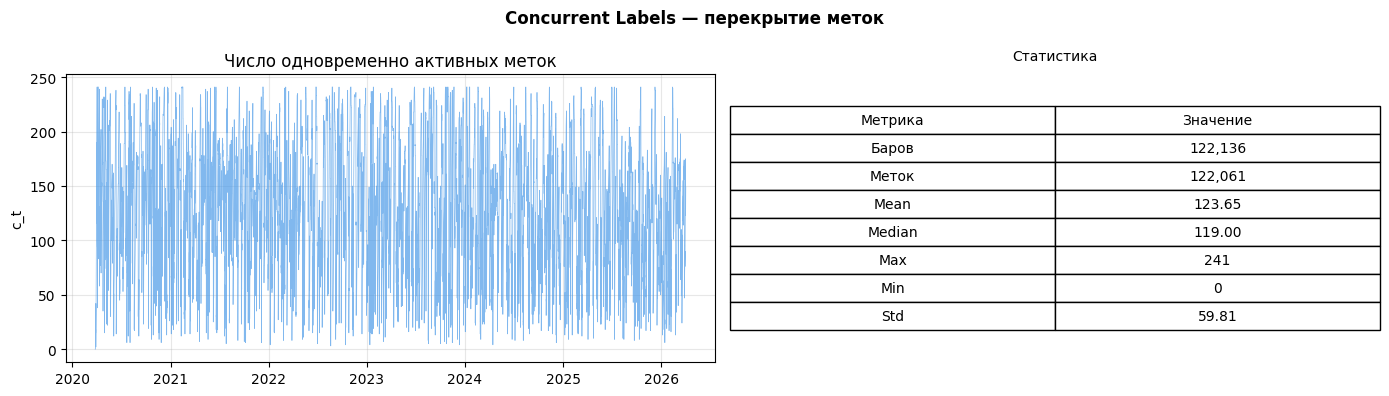

In [ ]:
BARS_DIR = Path("data/bars")

df_bars = pd.read_parquet(BARS_DIR / "dollar_bars_db_30m.parquet")
df_bars["dt"] = pd.to_datetime(df_bars["dt"])
df_bars = df_bars.set_index("dt").sort_index()
df_bars = df_bars[~df_bars.index.duplicated(keep="first")]
close   = df_bars["close"]

df_labels = pd.read_parquet(BARS_DIR / "labels_tb_mult2_h5d.parquet")
df_labels.index = pd.to_datetime(df_labels.index)
df_labels = df_labels.sort_index()
df_labels = df_labels[~df_labels.index.duplicated(keep="first")]

t1 = pd.to_datetime(df_labels["t1"]).fillna(close.index[-1])

bar_idx   = close.index.values.astype(np.int64)
t0_arr    = t1.index.values.astype(np.int64)
t1_arr    = t1.values.astype(np.int64)

sort_idx  = np.argsort(t0_arr)
t0_sorted = t0_arr[sort_idx]
t1_sorted = t1_arr[sort_idx]

count = np.zeros(len(bar_idx), dtype=np.int32)
for i, bar in enumerate(bar_idx):
    right = np.searchsorted(t0_sorted, bar, side="right")
    if right == 0:
        continue
    count[i] = np.sum(t1_sorted[:right] >= bar)

num_co_events = pd.Series(count, index=close.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Concurrent Labels — перекрытие меток", fontsize=12, fontweight="bold")

axes[0].plot(num_co_events.index, num_co_events.values,
             linewidth=0.5, alpha=0.7, color="#4C9BE8")
axes[0].set_title("Число одновременно активных меток")
axes[0].set_ylabel("c_t")
axes[0].grid(alpha=0.3)

stats = [
    ["Баров",   f"{len(close):,}"],
    ["Меток",   f"{len(t1):,}"],
    ["Mean",    f"{num_co_events.mean():.2f}"],
    ["Median",  f"{num_co_events.median():.2f}"],
    ["Max",     f"{num_co_events.max():.0f}"],
    ["Min",     f"{num_co_events.min():.0f}"],
    ["Std",     f"{num_co_events.std():.2f}"],
]

axes[1].axis("off")
tbl = axes[1].table(cellText=stats, colLabels=["Метрика", "Значение"],
                    cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.8)
axes[1].set_title("Статистика", fontsize=10, pad=10)

plt.tight_layout()
plt.show()


# Вывод 1

Медиана `c_t = 119` — в типичный момент времени каждый бар перекрывается с **119 другими метками одновременно**. Максимум достигает 241. Это означает что средняя уникальность наблюдения `ū ≈ 1/119 ≈ 0.008` — каждая метка несёт лишь ~0.8% уникальной информации, остальные 99.2% уже содержатся в соседних метках.

Без sample weights модель будет обучаться так, как будто у неё 122,061 независимых наблюдений. На самом деле эффективный размер выборки значительно меньше. Следующий шаг — вычислить веса наблюдений через return attribution и снизить влияние перекрывающихся меток.

# Визуализация перекрытий во времени

Смотрим как `c_t` и уникальность меток менялись на протяжении всей истории 2020–2026 — в связке с ценой BTC. Это помогает понять в какие периоды перекрытие было максимальным и как это соотносится с рыночными режимами.

C:\Users\User\AppData\Local\Temp\ipykernel_21104\3854476342.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


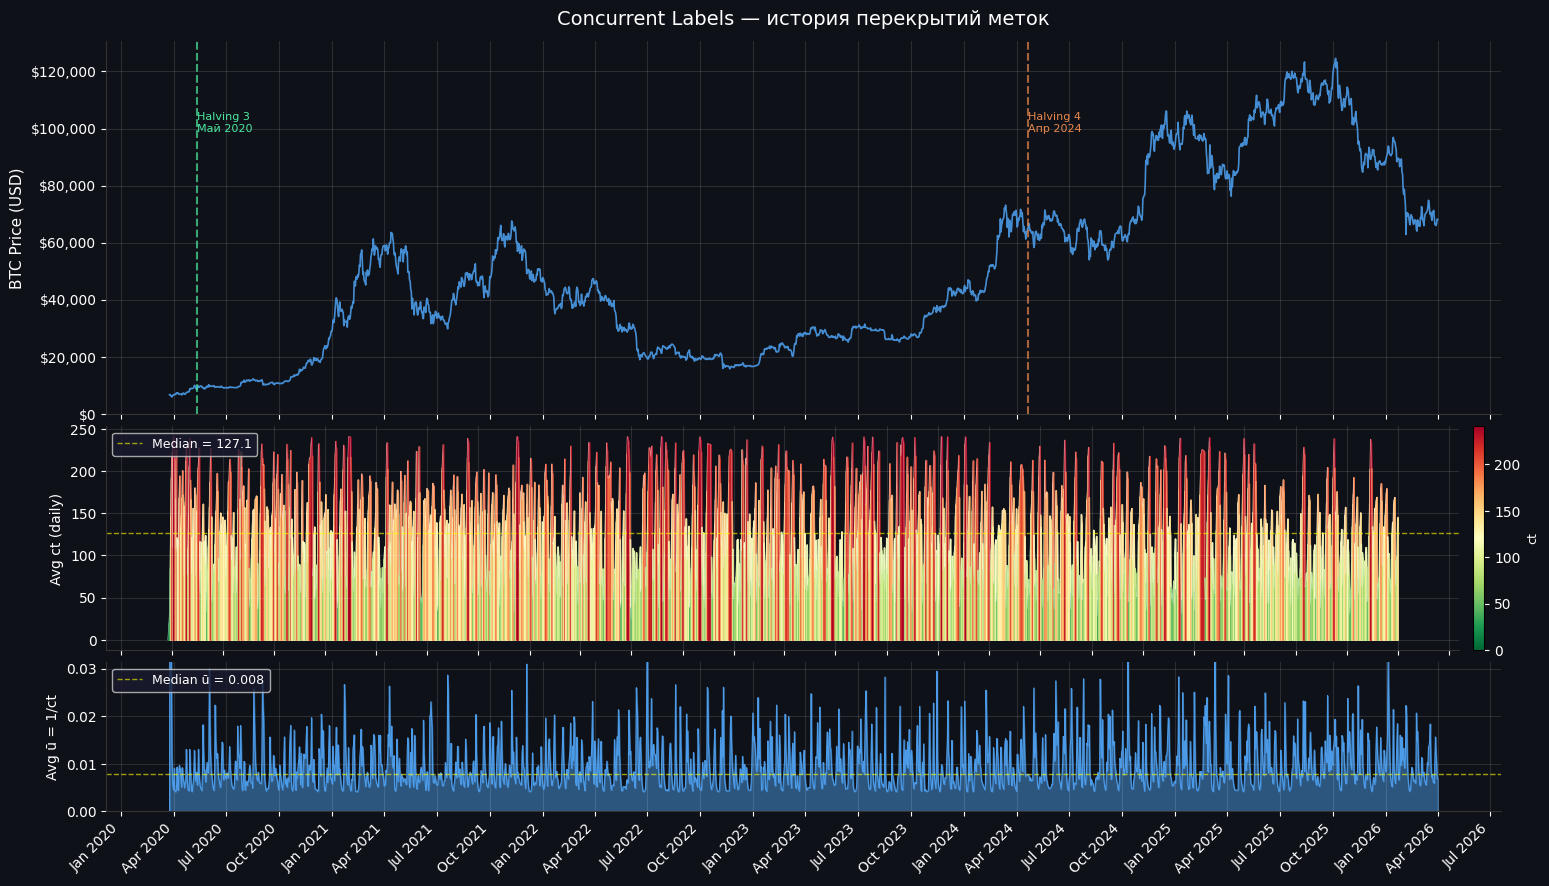

In [4]:


daily_ct    = num_co_events.resample("1D").mean().dropna()
daily_close = close.resample("1D").last().dropna()

for s in [daily_ct, daily_close]:
    if s.index.tz:
        s.index = s.index.tz_localize(None)

common      = daily_ct.index.intersection(daily_close.index)
daily_ct    = daily_ct.loc[common]
daily_close = daily_close.loc[common]
daily_u     = (1.0 / daily_ct.replace(0, np.nan)).fillna(0)

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor("#0e1117")
gs  = gridspec.GridSpec(3, 1, hspace=0.05, height_ratios=[2.5, 1.5, 1])

BG      = "#0e1117"
SPINE   = "#333333"
GRID    = {"alpha": 0.12, "color": "white"}
TICK_KW = {"colors": "white"}

def style_ax(ax, bottom=False):
    ax.set_facecolor(BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(SPINE)
    ax.spines["bottom"].set_color(SPINE)
    ax.tick_params(**TICK_KW, labelbottom=bottom)
    ax.grid(**GRID)

ax1 = fig.add_subplot(gs[0])
style_ax(ax1)
ax1.plot(daily_close.index, daily_close.values,
         color="#4C9BE8", linewidth=1.2, alpha=0.9)
ax1.set_ylabel("BTC Price (USD)", color="white", fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.set_title("Concurrent Labels — история перекрытий меток",
              color="white", fontsize=14, pad=12)

halvings = [
    ("Halving 3\nМай 2020", pd.Timestamp("2020-05-11"), "#4CE8A0"),
    ("Halving 4\nАпр 2024", pd.Timestamp("2024-04-20"), "#E8874C"),
]
y_top = daily_close.max()
for label, dt, color in halvings:
    if dt > daily_close.index[0]:
        ax1.axvline(dt, color=color, linewidth=1.5, linestyle="--", alpha=0.7)
        ax1.text(dt, y_top * 0.85, label, color=color,
                 fontsize=8, ha="left", va="top")

ax2 = fig.add_subplot(gs[1], sharex=ax1)
style_ax(ax2)

norm = plt.Normalize(daily_ct.min(), daily_ct.max())
cmap = plt.cm.RdYlGn_r

for i in range(len(daily_ct) - 1):
    ax2.fill_between(
        [daily_ct.index[i], daily_ct.index[i+1]],
        [0, 0],
        [daily_ct.iloc[i], daily_ct.iloc[i+1]],
        color=cmap(norm(daily_ct.iloc[i])), alpha=0.8
    )

ax2.plot(daily_ct.index, daily_ct.values, color="white", linewidth=0.5, alpha=0.4)
ax2.axhline(daily_ct.median(), color="yellow", linewidth=1,
            linestyle="--", alpha=0.6, label=f"Median = {daily_ct.median():.1f}")
ax2.set_ylabel("Avg ct (daily)", color="white", fontsize=10)
ax2.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=9, loc="upper left")

sm   = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2, orientation="vertical", pad=0.01, fraction=0.02)
cbar.ax.yaxis.set_tick_params(color="white")
cbar.set_label("ct", color="white", fontsize=9)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

ax3 = fig.add_subplot(gs[2], sharex=ax1)
style_ax(ax3, bottom=True)

ax3.fill_between(daily_u.index, 0, daily_u.values, color="#4C9BE8", alpha=0.5)
ax3.plot(daily_u.index, daily_u.values, color="#4C9BE8", linewidth=0.8)
ax3.axhline(daily_u.median(), color="yellow", linewidth=1,
            linestyle="--", alpha=0.6, label=f"Median ū = {daily_u.median():.3f}")
ax3.set_ylabel("Avg ū = 1/ct", color="white", fontsize=10)
ax3.set_ylim(0, daily_u.quantile(0.99) * 1.2)
ax3.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=9, loc="upper left")

ax3.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha="right", color="white")

plt.tight_layout()
plt.show()


# Вывод 2

`c_t` стабильно высокий на всём периоде — медиана 127, и нет выраженной связи с ценовыми режимами. Перекрытие одинаково высокое и в боковике 2022–2023, и в бычьем рынке 2024–2025. Это ожидаемо: горизонт 5 дней на барах ~30m даёт ~240 перекрывающихся баров по конструкции — независимо от волатильности.

Уникальность `ū = 1/ct` держится около 0.008 на всей истории. Единственные всплески — начало 2020 года когда баров было мало и перекрытий ещё не накопилось. После июля 2020 система вошла в стационарный режим.

Вывод практический: sample weights необходимы. Без них все 122,061 наблюдение будут считаться независимыми, хотя реально эффективный размер выборки в ~120 раз меньше.

# Sample Weights — Return Attribution

Вычисляем вес каждого наблюдения пропорционально уникальному абсолютному return который оно несёт — с поправкой на перекрытие с другими метками:

```
w_i = |Σ(r_t / c_t)|   за период [t0, t1]
```

Бар с сильным движением и низким перекрытием получает высокий вес. Бар со слабым движением в период высокого перекрытия — низкий. После вычисления веса нормируются так чтобы их сумма равнялась N.



C:\Users\User\AppData\Local\Temp\ipykernel_21104\1965402350.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


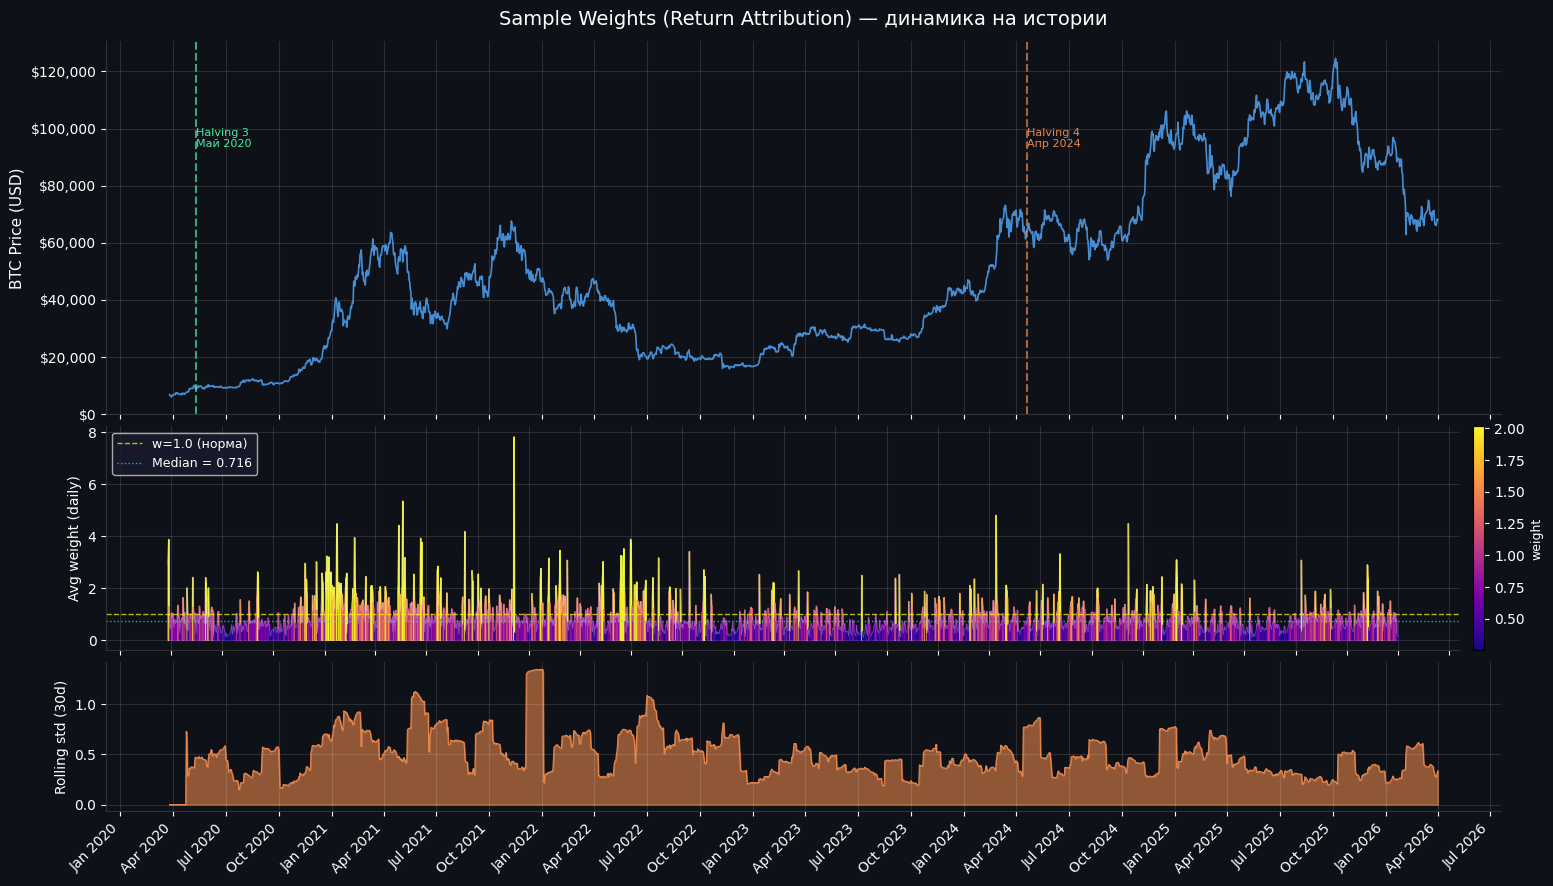

In [5]:

BARS_DIR = Path("data/bars")

log_ret     = np.log(close).diff()
log_ret     = log_ret[~log_ret.index.duplicated(keep="first")]

bar_idx_ns  = close.index.values.astype(np.int64)
t0_arr      = t1.index.values.astype(np.int64)
t1_arr      = t1.values.astype(np.int64)
log_ret_arr = log_ret.reindex(close.index).fillna(0).values
ct_arr      = np.where(num_co_events.reindex(close.index).fillna(1).values == 0, 1,
                       num_co_events.reindex(close.index).fillna(1).values)

bar_sort    = np.argsort(bar_idx_ns)
bar_sorted  = bar_idx_ns[bar_sort]

weights_raw = np.zeros(len(t0_arr), dtype=np.float64)

for i in range(len(t0_arr)):
    t0_ns = t0_arr[i]
    t1_ns = t1_arr[i]
    left  = np.searchsorted(bar_sorted, t0_ns, side="left")
    right = np.searchsorted(bar_sorted, t1_ns, side="right")

    if left >= right:
        weights_raw[i] = 1e-6
        continue

    orig_idx       = bar_sort[left:right]
    weights_raw[i] = np.abs((log_ret_arr[orig_idx] / ct_arr[orig_idx]).sum())

N       = len(weights_raw)
weights = weights_raw * N / weights_raw.sum()

df_weights = pd.DataFrame({
    "t0":    t1.index,
    "t1":    t1.values,
    "bin":   df_labels["bin"].values,
    "w_raw": weights_raw,
    "w":     weights,
}, index=t1.index)

df_weights.to_parquet(BARS_DIR / "labels_tb_mult2_h5d.parquet", compression="snappy")


def strip_tz(s):
    if hasattr(s.index, "tz") and s.index.tz is not None:
        s.index = s.index.tz_localize(None)
    return s

daily_w       = strip_tz(df_weights["w"].resample("1D").mean().dropna())
daily_close_w = strip_tz(close.resample("1D").last().dropna())
common        = daily_w.index.intersection(daily_close_w.index)
daily_w       = daily_w.loc[common]
daily_close_w = daily_close_w.loc[common]

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor("#0e1117")
gs  = gridspec.GridSpec(3, 1, hspace=0.05, height_ratios=[2.5, 1.5, 1])

BG     = "#0e1117"
SPINE  = "#333333"

def style_ax(ax, bottom=False):
    ax.set_facecolor(BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(SPINE)
    ax.spines["bottom"].set_color(SPINE)
    ax.tick_params(colors="white", labelbottom=bottom)
    ax.grid(alpha=0.12, color="white")

ax1 = fig.add_subplot(gs[0])
style_ax(ax1)
ax1.plot(daily_close_w.index, daily_close_w.values,
         color="#4C9BE8", linewidth=1.2, alpha=0.9)
ax1.set_ylabel("BTC Price (USD)", color="white", fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.set_title("Sample Weights (Return Attribution) — динамика на истории",
              color="white", fontsize=14, pad=12)

halvings = [
    ("Halving 3\nМай 2020", pd.Timestamp("2020-05-11"), "#4CE8A0"),
    ("Halving 4\nАпр 2024", pd.Timestamp("2024-04-20"), "#E8874C"),
]
for label, dt, color in halvings:
    if daily_close_w.index[0] <= dt <= daily_close_w.index[-1]:
        ax1.axvline(dt, color=color, linewidth=1.5, linestyle="--", alpha=0.7)
        ax1.text(dt, daily_close_w.max() * 0.75, label,
                 color=color, fontsize=8, ha="left")

ax2 = fig.add_subplot(gs[1], sharex=ax1)
style_ax(ax2)

norm = plt.Normalize(daily_w.quantile(0.05), daily_w.quantile(0.95))
cmap = plt.cm.plasma

for i in range(len(daily_w) - 1):
    ax2.fill_between(
        [daily_w.index[i], daily_w.index[i+1]], [0, 0],
        [daily_w.iloc[i], daily_w.iloc[i+1]],
        color=cmap(norm(daily_w.iloc[i])), alpha=0.8
    )

ax2.plot(daily_w.index, daily_w.values, color="white", linewidth=0.5, alpha=0.3)
ax2.axhline(1.0, color="yellow", linewidth=1, linestyle="--",
            alpha=0.7, label="w=1.0 (норма)")
ax2.axhline(daily_w.median(), color="cyan", linewidth=1, linestyle=":",
            alpha=0.7, label=f"Median = {daily_w.median():.3f}")
ax2.set_ylabel("Avg weight (daily)", color="white", fontsize=10)
ax2.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=9, loc="upper left")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2, orientation="vertical", pad=0.01, fraction=0.02)
cbar.ax.yaxis.set_tick_params(color="white")
cbar.set_label("weight", color="white", fontsize=9)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

ax3 = fig.add_subplot(gs[2], sharex=ax1)
style_ax(ax3, bottom=True)

roll_std = daily_w.rolling(30).std().fillna(0)
ax3.fill_between(daily_w.index, 0, roll_std.values, color="#E8874C", alpha=0.6)
ax3.plot(daily_w.index, roll_std.values, color="#E8874C", linewidth=0.8)
ax3.set_ylabel("Rolling std (30d)", color="white", fontsize=10)

ax3.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha="right", color="white")

plt.tight_layout()
plt.show()


# Sample Weights — интерпретация результатов

### Нормализация весов

Веса нормализованы так что `sum(w) = N` и `mean(w) = 1.0` — стандарт sklearn:

```
w > 1  → наблюдение важнее среднего: сильное движение + низкий overlap
w < 1  → наблюдение менее важно:     слабое движение  + высокий overlap
w = 1  → среднее наблюдение
```

---

### Что показывает график

Веса выше 1 появляются в периоды сильных направленных движений с относительно низким перекрытием меток: bull run 2020–2021, краш с $65K до $30K в мае 2021, Luna crash и FTX в 2022, пост-ETF рост до $126K в 2024–2025.

Медиана = **0.716** — большинство наблюдений весят меньше нормы. Это прямое следствие высокого `c_t ≈ 127`: overlap делит return каждого бара на 127 частей, и большинство наблюдений несут мало уникальной информации. Редкие кризисные события получают вес 4–8x — именно на них модель должна учиться сильнее.

Rolling std (нижний график) подтверждает: дисперсия весов максимальна в кризисные периоды и минимальна в боковиках — система корректно расставляет акценты.

---

### Как используются веса при обучении

```python
model.fit(X_train, y_train, sample_weight=weights[train_idx])
```

Наблюдения с высоким весом вносят больший вклад в функцию потерь — модель сильнее штрафуется за ошибки на информативных барах и мягче реагирует на шумные периоды с высоким overlap.

# Time Decay — затухание весов старых наблюдений

Рыночные режимы меняются. Паттерны 2020 года могут не работать в 2025 — рынок адаптируется, ликвидность растёт, участники меняются. Time decay снижает вес старых наблюдений: чем старше наблюдение, тем меньше его влияние на обучение модели.

Реализация из AFML (Snippet 4.11) — кусочно-линейное затухание поверх уже посчитанных sample weights:

```
финальный вес = sample_weight × time_decay_factor
```

Единственный параметр — `c`, вес самого старого наблюдения:

| c | Поведение |
|---|-----------|
| `1.0` | нет затухания — все наблюдения равны |
| `0.5` | линейное затухание, все веса > 0 |
| `0.0` | самые старые наблюдения получают вес → 0 |
| `-0.25` | старые 25% наблюдений обнуляются полностью |
| `-0.5` | старые 50% наблюдений обнуляются полностью |

Отрицательный `c` означает что часть истории полностью исключается из обучения — модель видит только последние `(1 + c) × 100%` наблюдений.

---

### Как выбрать c

Нет универсального правила — зависит от того насколько быстро меняется рынок. Для BTC 2020–2026 рынок прошёл через несколько принципиально разных режимов: низкая ликвидность 2020, два bull run, два краша, институциональное принятие 2024. Слишком агрессивное затухание (c = −0.5) отрежет половину истории включая оба халвинга. Слишком мягкое (c = 1.0) не даст никакого эффекта.

Тестируем шесть вариантов: `1.0, 0.5, 0.0, −0.1, −0.25, −0.5` — и смотрим как меняется распределение финальных весов и доля обнулённых наблюдений.

C:\Users\User\AppData\Local\Temp\ipykernel_21104\1320921741.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


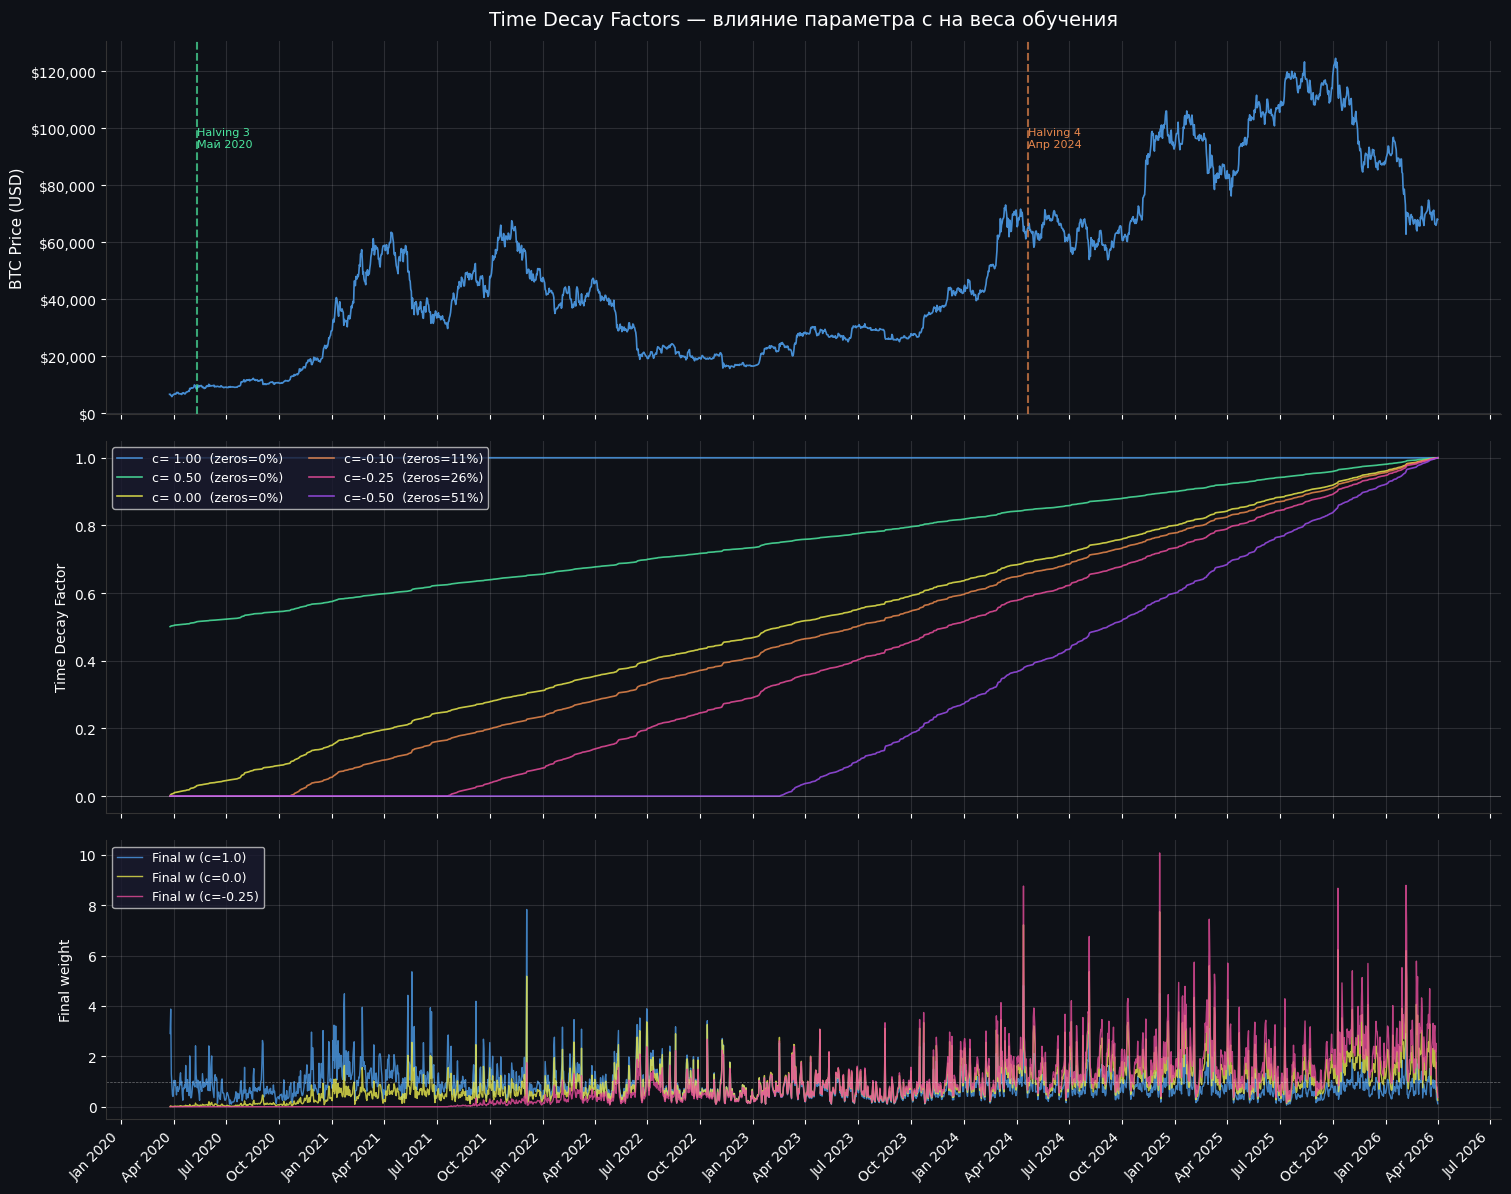

In [6]:
def getTimeDecay(tW, clfLastW=1.0):
    clfW = tW.sort_index().cumsum()
    if clfLastW >= 0:
        slope = (1.0 - clfLastW) / clfW.iloc[-1]
    else:
        slope = 1.0 / ((clfLastW + 1) * clfW.iloc[-1])
    const      = 1.0 - slope * clfW.iloc[-1]
    clfW       = const + slope * clfW
    clfW[clfW < 0] = 0
    return clfW


bar_idx_ns = close.index.values.astype(np.int64)
bar_sort   = np.argsort(bar_idx_ns)
bar_sorted = bar_idx_ns[bar_sort]
ct_full    = np.where(num_co_events.reindex(close.index).fillna(1).values == 0, 1,
                      num_co_events.reindex(close.index).fillna(1).values)

t0_ns     = t1.index.values.astype(np.int64)
t1_ns     = t1.values.astype(np.int64)
avg_u_arr = np.zeros(len(t1))

for i in range(len(t1)):
    left  = np.searchsorted(bar_sorted, t0_ns[i], side="left")
    right = np.searchsorted(bar_sorted, t1_ns[i], side="right")
    if left >= right:
        avg_u_arr[i] = 1.0
        continue
    avg_u_arr[i] = (1.0 / ct_full[bar_sort[left:right]]).mean()

avg_u = pd.Series(avg_u_arr, index=t1.index).sort_index()

c_values      = [1.0, 0.5, 0.0, -0.1, -0.25, -0.5]
line_colors   = ["#4C9BE8", "#4CE8A0", "#E8E84C", "#E8874C", "#E84C9B", "#9B4CE8"]
decay_results = {c: getTimeDecay(avg_u, clfLastW=c) for c in c_values}

final_weights = {}
for c in c_values:
    d  = decay_results[c].reindex(df_weights.index).fillna(0)
    fw = df_weights["w"] * d
    final_weights[c] = fw * len(fw) / fw.sum() if fw.sum() > 0 else fw


def strip_tz(s):
    if hasattr(s.index, "tz") and s.index.tz is not None:
        s.index = s.index.tz_localize(None)
    return s

daily_close_p = strip_tz(close.resample("1D").last().dropna())

BG    = "#0e1117"
SPINE = "#333333"

def style_ax(ax, bottom=False):
    ax.set_facecolor(BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(SPINE)
    ax.spines["bottom"].set_color(SPINE)
    ax.tick_params(colors="white", labelbottom=bottom)
    ax.grid(alpha=0.12, color="white")

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(3, 1, hspace=0.08, height_ratios=[2, 2, 1.5])

ax1 = fig.add_subplot(gs[0])
style_ax(ax1)
ax1.plot(daily_close_p.index, daily_close_p.values,
         color="#4C9BE8", linewidth=1.2, alpha=0.9)
ax1.set_ylabel("BTC Price (USD)", color="white", fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.set_title("Time Decay Factors — влияние параметра c на веса обучения",
              color="white", fontsize=14, pad=12)

halvings = [
    ("Halving 3\nМай 2020", pd.Timestamp("2020-05-11"), "#4CE8A0"),
    ("Halving 4\nАпр 2024", pd.Timestamp("2024-04-20"), "#E8874C"),
]
for label, dt, color in halvings:
    if daily_close_p.index[0] <= dt <= daily_close_p.index[-1]:
        ax1.axvline(dt, color=color, linewidth=1.5, linestyle="--", alpha=0.7)
        ax1.text(dt, daily_close_p.max() * 0.75, label,
                 color=color, fontsize=8, ha="left")

ax2 = fig.add_subplot(gs[1], sharex=ax1)
style_ax(ax2)

for c, color in zip(c_values, line_colors):
    d         = strip_tz(decay_results[c].copy())
    daily_d   = d.resample("1D").mean().dropna()
    zeros_pct = (d == 0).mean() * 100
    ax2.plot(daily_d.index, daily_d.values, color=color, linewidth=1.2,
             alpha=0.85, label=f"c={c:>5.2f}  (zeros={zeros_pct:.0f}%)")

ax2.axhline(0, color="white", linewidth=0.5, alpha=0.3)
ax2.set_ylabel("Time Decay Factor", color="white", fontsize=10)
ax2.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=9,
           loc="upper left", ncol=2)

ax3 = fig.add_subplot(gs[2], sharex=ax1)
style_ax(ax3, bottom=True)

for c, color in zip([1.0, 0.0, -0.25], ["#4C9BE8", "#E8E84C", "#E84C9B"]):
    fw       = strip_tz(final_weights[c].copy())
    daily_fw = fw.resample("1D").mean().dropna()
    ax3.plot(daily_fw.index, daily_fw.values, color=color, linewidth=1.0,
             alpha=0.8, label=f"Final w (c={c})")

ax3.axhline(1.0, color="white", linewidth=0.5, linestyle="--", alpha=0.4)
ax3.set_ylabel("Final weight", color="white", fontsize=10)
ax3.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=9, loc="upper left")

ax3.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha="right", color="white")

plt.tight_layout()
plt.show()


# Финальные веса — сохранение

Выбираем `c = 0.0` — decay плавно убывает от 1.0 до 0 на всей истории, все наблюдения остаются активными. Умножаем sample weights на decay factor и нормализуем сумму к N.

Итоговый датафрейм содержит четыре колонки: `t1` — конец интервала метки, `bin` — метка {−1, 0, +1}, `w` — return attribution вес, `w_final` — финальный вес после time decay. Именно `w_final` передаётся в `sample_weight` при обучении модели.

In [7]:

BARS_DIR = Path("data/bars")

chosen_c  = 0.0
d         = getTimeDecay(avg_u, clfLastW=chosen_c)
d_aligned = d.reindex(df_weights.index).fillna(0)
w_final   = df_weights["w"] * d_aligned
N         = len(w_final)
w_final   = w_final * N / w_final.sum()

df_final            = df_weights[["t1", "bin", "w"]].copy()
df_final["decay"]   = d_aligned.values
df_final["w_final"] = w_final.values

path_out = BARS_DIR / "sample_weights_final_c0.parquet"
df_final.to_parquet(path_out, compression="snappy")

print(f"N: {len(df_final):,}  |  Mean: {df_final['w_final'].mean():.4f}  |  "
      f"Median: {df_final['w_final'].median():.4f}  |  Max: {df_final['w_final'].max():.4f}")
print(f"Decay range: {d_aligned.min():.4f} → {d_aligned.max():.4f}")
print(f"Сохранено: {path_out.name}")


N: 122,061  |  Mean: 1.0000  |  Median: 0.6800  |  Max: 43.7842
Decay range: 0.0006 → 1.0000
Сохранено: sample_weights_final_c0.parquet


# Сравнение весов: без затухания vs с time decay

Визуализируем разницу между двумя подходами — исходные sample weights (`c=1.0`) и финальные веса с time decay (`c=0.0`) на одном графике. Закрашенные области показывают где один подход даёт больший вес чем другой — это наглядно показывает как time decay перераспределяет влияние наблюдений от ранней истории к поздней.

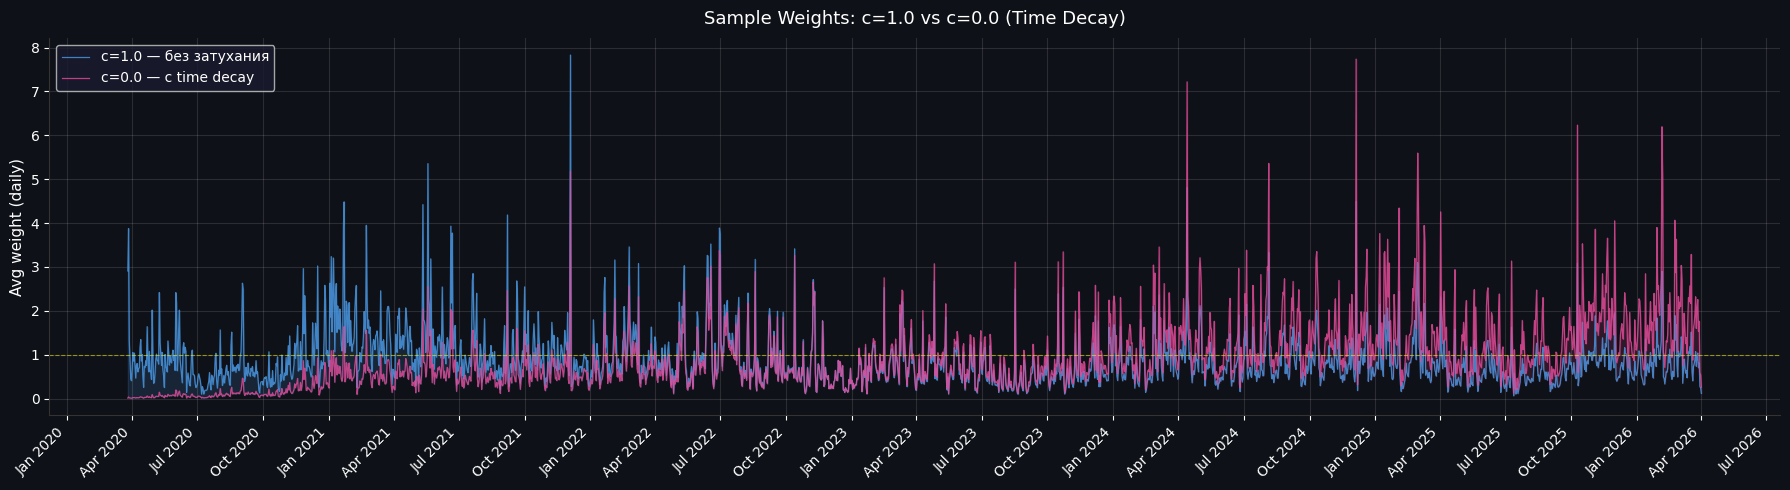

In [8]:
def strip_tz(s):
    if hasattr(s.index, "tz") and s.index.tz is not None:
        s.index = s.index.tz_localize(None)
    return s

w_no_decay   = strip_tz(df_weights["w"].resample("1D").mean().dropna())
w_with_decay = strip_tz(final_weights[0.0].resample("1D").mean().dropna())

common       = w_no_decay.index.intersection(w_with_decay.index)
w_no_decay   = w_no_decay.loc[common]
w_with_decay = w_with_decay.loc[common]

fig, ax = plt.subplots(figsize=(18, 5))
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

ax.plot(w_no_decay.index,   w_no_decay.values,   color="#4C9BE8",
        linewidth=0.9, alpha=0.8, label="c=1.0 — без затухания")
ax.plot(w_with_decay.index, w_with_decay.values, color="#E84C9B",
        linewidth=0.9, alpha=0.8, label="c=0.0 — с time decay")

ax.fill_between(common, w_no_decay.values, w_with_decay.values,
                where=(w_with_decay.values >  w_no_decay.values),
                color="#E84C9B", alpha=0.15)
ax.fill_between(common, w_no_decay.values, w_with_decay.values,
                where=(w_with_decay.values <= w_no_decay.values),
                color="#4C9BE8", alpha=0.15)

ax.axhline(1.0, color="yellow", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_ylabel("Avg weight (daily)", color="white", fontsize=11)
ax.set_title("Sample Weights: c=1.0 vs c=0.0 (Time Decay)",
             color="white", fontsize=13, pad=10)

ax.tick_params(colors="white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#333")
ax.spines["bottom"].set_color("#333")
ax.grid(alpha=0.12, color="white")
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=10, loc="upper left")

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right", color="white")

plt.tight_layout()
plt.show()